# 回帰分析：ODA プロジェクト評価 (PCA適用版)

目的変数: total_eval

対数化する変数:
- project_cost_plan
- project_cost_act
- project_duration_act
- project_duration_plan
- population

PCA合成変数:
- pc1_freedom (freedom_house_score, voice_and_accountability)
- pc1_governance (control_of_corruption, government_effectiveness, rule_of_law)

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from linearmodels.panel import PanelOLS
import warnings
warnings.filterwarnings('ignore')

print("ライブラリのインポート完了")

ライブラリのインポート完了


## 1. データ読み込み

In [102]:
# データ読み込み
df = pd.read_csv("../df_check_99.csv", index_col=0)
print(f"データ形状: {df.shape}")
print(f"\n列名:\n{df.columns.tolist()}")

データ形状: (2227, 68)

列名:
['file', 'country', 'eval_year', 'evaluator_group', 'evaluator', 'project_cost_plan', 'project_cost_act', 'プロジェクト期間開始_計画時', 'プロジェクト期間終了_計画時', 'プロジェクト期間開始_実績', 'プロジェクト期間終了_実績', 'project_duration_plan', 'project_duration_act', '効率性_コスト', '効率性_期間', '総合評価', 'type', '分野', '案件名', '連番', 'region', 'region_detail', 'alpha2', 'alpha3', 'project_start_year', 'project_end_year', 'join_flg', 'control_of_corruption', 'government_effectiveness', 'political_stability', 'regulatory_quality', 'rule_of_law', 'voice_and_accountability', 'freedom_house_score', 'gdp_growth', 'Year', 'population', 'external_eval_flg', 'total_eval', 'evaluator_avg_other_pjt', 'その他_flg_fix', 'インフラ_flg_fix', 'エネルギー一般_flg_fix', '人材・教育_flg_fix', '保健・社会福祉_flg_fix', '公益事業一般_flg_fix', '商業経営_flg_fix', '工業_flg_fix', '放送_flg_fix', '林業・森林保全_flg_fix', '水産_flg_fix', '水資源開発_flg_fix', '海運_flg_fix', '測量・地図_flg_fix', '災害・食料援助_flg_fix', '災害対策_flg_fix', '環境_flg_fix', '畜産_flg_fix', '社会基盤一般_flg_fix', '航空・空港_flg_fix', '行政一般_

## 2. データ前処理

In [103]:
# カテゴリ変数の型変換
df['region_detail'] = df['region_detail'].astype('category')
df['eval_year'] = df['eval_year'].astype('category')
df['type'] = df['type'].astype('category')
df['country'] = df['country'].astype('category')

# external_eval_flgの型変換
if 'external_eval_flg' in df.columns:
    df['external_eval_flg'] = df['external_eval_flg'].astype('category')

# evaluator_groupの型変換
if 'evaluator_group' in df.columns:
    df['evaluator_group'] = df['evaluator_group'].astype('category')

# evaluatorの型変換
if 'evaluator' in df.columns:
    df['evaluator'] = df['evaluator'].astype('category')

print("カテゴリ変数の型変換完了")

カテゴリ変数の型変換完了


In [104]:
# 基準カテゴリの設定（全体平均に最も近い地域を基準に）
region_means = df.groupby('region_detail')['total_eval'].mean()
overall_mean = df['total_eval'].mean()
closest_region = (region_means - overall_mean).abs().idxmin()

print(f"ベースグループ (region): {closest_region}")

# カテゴリの順序を設定（基準カテゴリを最初に）
region_cats = [closest_region] + [r for r in df['region_detail'].cat.categories if r != closest_region]
df['region_detail'] = df['region_detail'].cat.reorder_categories(region_cats)

# eval_yearの基準を2015に設定
if 2015 in df['eval_year'].cat.categories:
    year_cats = [2015] + [y for y in df['eval_year'].cat.categories if y != 2015]
    df['eval_year'] = df['eval_year'].cat.reorder_categories(year_cats)
    print("ベースグループ (eval_year): 2015")

ベースグループ (region): ミクロネシア
ベースグループ (eval_year): 2015


## 3. 対数変換

In [105]:
# 対数変換する変数
cols_log = [
    "project_cost_plan",
    "project_cost_act",
    "project_duration_act",
    "project_duration_plan",
    "population"
]

# 対数変換（0以下の値はNaNに）
for col in cols_log:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: np.log(x) if pd.notna(x) and x > 0 else np.nan)
        print(f"{col}: 対数変換完了")

print("\n対数変換完了")

project_cost_plan: 対数変換完了
project_cost_act: 対数変換完了
project_duration_act: 対数変換完了
project_duration_plan: 対数変換完了
population: 対数変換完了

対数変換完了


## 4. PCA（主成分分析）による多重共線性対策

In [106]:
def perform_pca(data, vars_list, pc_name):
    """
    主成分分析を実行し、第1主成分のスコアを返す
    
    Parameters:
    -----------
    data : DataFrame
        元データ
    vars_list : list
        PCAに使用する変数のリスト
    pc_name : str
        主成分の名前
    
    Returns:
    --------
    pc_scores : array
        第1主成分のスコア（欠損値はNaN）
    """
    # データの抽出
    data_subset = data[vars_list].copy()
    
    # 欠損値のない行を特定
    valid_rows = data_subset.notna().all(axis=1)
    
    if valid_rows.sum() == 0:
        print(f"警告: {pc_name}のPCAに使用できるデータがありません")
        return np.full(len(data), np.nan)
    
    # 標準化
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data_subset[valid_rows])
    
    # PCA実行
    pca = PCA(n_components=1)
    pca_result = pca.fit_transform(data_scaled)
    
    # 結果を格納
    pc_scores = np.full(len(data), np.nan)
    pc_scores[valid_rows] = pca_result[:, 0]
    
    # 情報表示
    print(f"\n{pc_name}:")
    print(f"  使用変数: {vars_list}")
    print(f"  有効サンプル数: {valid_rows.sum()}")
    print(f"  説明分散比率: {pca.explained_variance_ratio_[0]:.4f}")
    
    return pc_scores

# PCA実行
df['pc1_freedom'] = perform_pca(
    df, 
    vars_list=["freedom_house_score", "voice_and_accountability"],
    pc_name="pc1_freedom"
)

df['pc1_governance'] = perform_pca(
    df,
    vars_list=["control_of_corruption", "government_effectiveness", "rule_of_law"],
    pc_name="pc1_governance"
)

print("\nPCA処理完了")


pc1_freedom:
  使用変数: ['freedom_house_score', 'voice_and_accountability']
  有効サンプル数: 2165
  説明分散比率: 0.9867

pc1_governance:
  使用変数: ['control_of_corruption', 'government_effectiveness', 'rule_of_law']
  有効サンプル数: 2186
  説明分散比率: 0.8449

PCA処理完了


## 5. 説明変数の定義

In [107]:
# セクターフラグ変数
cat_flg = [col for col in df.columns if col.endswith('_flg_fix')]
print(f"セクターフラグ変数数: {len(cat_flg)}")

# その他の説明変数（PCA適用後）
others = [
    "project_cost_plan",
    "project_duration_plan",
    "gdp_growth",
    "population",
    "political_stability",
    "regulatory_quality",
    "freedom_house_score",
    "voice_and_accountability",
    "control_of_corruption",
    "government_effectiveness",
    "rule_of_law",
    "pc1_freedom",
    "pc1_governance"
]

# 実際に存在する変数のみを選択
others = [col for col in others if col in df.columns]
print(f"\nその他の説明変数数: {len(others)}")
print(f"変数リスト: {others}")

セクターフラグ変数数: 28

その他の説明変数数: 13
変数リスト: ['project_cost_plan', 'project_duration_plan', 'gdp_growth', 'population', 'political_stability', 'regulatory_quality', 'freedom_house_score', 'voice_and_accountability', 'control_of_corruption', 'government_effectiveness', 'rule_of_law', 'pc1_freedom', 'pc1_governance']


## 6. 欠損値の確認

In [108]:
# 主要変数の欠損値確認
key_vars = ['total_eval'] + others + ['type', 'region_detail', 'eval_year']
missing_info = df[key_vars].isnull().sum()
missing_pct = (missing_info / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    '欠損数': missing_info,
    '欠損率(%)': missing_pct
})

print("主要変数の欠損値情報:")
print(missing_df[missing_df['欠損数'] > 0].sort_values('欠損数', ascending=False))

主要変数の欠損値情報:
                          欠損数  欠損率(%)
project_duration_plan      69    3.10
freedom_house_score        62    2.78
pc1_freedom                62    2.78
total_eval                 50    2.25
gdp_growth                 41    1.84
regulatory_quality         41    1.84
control_of_corruption      41    1.84
government_effectiveness   41    1.84
pc1_governance             41    1.84
population                 39    1.75
political_stability        39    1.75
voice_and_accountability   39    1.75
rule_of_law                39    1.75
project_cost_plan          29    1.30
region_detail              15    0.67


## 7. 回帰分析用データの準備

In [109]:
# 分析に使用する変数を全て含む行のみを抽出
analysis_vars = ['total_eval'] + others + cat_flg + ['type', 'region_detail', 'eval_year', 'external_eval_flg']
analysis_vars = [v for v in analysis_vars if v in df.columns]

# 欠損値を除外
df_analysis = df[analysis_vars].dropna()

print(f"元のデータ行数: {len(df)}")
print(f"分析用データ行数: {len(df_analysis)}")
print(f"除外された行数: {len(df) - len(df_analysis)}")

元のデータ行数: 2227
分析用データ行数: 2065
除外された行数: 162


## 8. モデル1: プーリングOLS回帰

In [110]:
# 説明変数のリストを作成
X_vars = others + cat_flg

# 日本語や特殊文字を含む変数名を全てQ()でエスケープ
def escape_var_name(var):
    """変数名にスペース、ハイフン、日本語が含まれる場合はQ()でエスケープ"""
    # 日本語文字が含まれているかチェック
    has_japanese = any('\u3040' <= c <= '\u309F' or  # ひらがな
                       '\u30A0' <= c <= '\u30FF' or  # カタカナ
                       '\u4E00' <= c <= '\u9FFF'     # 漢字
                       for c in var)
    
    if ' ' in var or '-' in var or '・' in var or has_japanese:
        return f"Q('{var}')"
    return var

# 説明変数の式を作成
formula_parts = [escape_var_name(var) for var in X_vars]
formula = "total_eval ~ " + " + ".join(formula_parts) + " + C(type) + C(region_detail) + C(eval_year) + C(external_eval_flg)"

print("モデル1: プーリングOLS")
print(f"サンプルサイズ: {len(df_analysis)}")
print(f"\n最初の100文字の式: {formula[:100]}...")

# モデル推定
model1 = smf.ols(formula, data=df_analysis).fit()

print("\n推定完了")
print(f"R-squared: {model1.rsquared:.4f}")
print(f"Adj. R-squared: {model1.rsquared_adj:.4f}")
print(f"観測数: {model1.nobs}")

モデル1: プーリングOLS
サンプルサイズ: 2065

最初の100文字の式: total_eval ~ project_cost_plan + project_duration_plan + gdp_growth + population + political_stabili...

推定完了
R-squared: 0.1815
Adj. R-squared: 0.1506
観測数: 2065.0


In [111]:
# モデル1の結果サマリー
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:             total_eval   R-squared:                       0.182
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     5.881
Date:                Fri, 02 Jan 2026   Prob (F-statistic):           7.54e-47
Time:                        06:54:37   Log-Likelihood:                -2380.4
No. Observations:                2065   AIC:                             4913.
Df Residuals:                    1989   BIC:                             5341.
Df Model:                          75                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

## 固定効果モデル


In [112]:
# 固定効果モデル用のデータ準備
df_fe = df.copy()

required_fe = ['project_start_year', 'country']
missing_fe = [c for c in required_fe if c not in df_fe.columns]
if missing_fe:
    raise ValueError(f"Missing required columns for fixed effects: {missing_fe}")
if 'evaluator_group' not in df_fe.columns:
    raise ValueError("Missing required column for FE2: evaluator_group")

# 固定効果列はカテゴリとして扱う
df_fe['project_start_year'] = df_fe['project_start_year'].astype(str)
df_fe['country'] = df_fe['country'].astype(str)
df_fe['evaluator_group'] = df_fe['evaluator_group'].astype(str)

# 欠損の除外（モデル1と同じ説明変数 + 固定効果列）
fe_vars = ['total_eval'] + X_vars + ['type', 'region_detail', 'eval_year', 'external_eval_flg', 'project_start_year', 'country', 'evaluator_group']
fe_vars = [v for v in fe_vars if v in df_fe.columns]
df_fe_analysis = df_fe[fe_vars].dropna()

print(f"固定効果モデル用データ行数: {len(df_fe_analysis)}")

# 固定効果を追加した式
formula_fe1 = formula + ' + C(project_start_year) + C(country)'
formula_fe2 = formula + ' + C(project_start_year) + C(country) + C(evaluator_group)'

print('モデルFE1: project_start_year + country 固定効果')
model_fe1 = smf.ols(formula_fe1, data=df_fe_analysis).fit()
print(model_fe1.summary())

print('モデルFE2: project_start_year + country + evaluator_group 固定効果')
model_fe2 = smf.ols(formula_fe2, data=df_fe_analysis).fit()
print(model_fe2.summary())


固定効果モデル用データ行数: 2065
モデルFE1: project_start_year + country 固定効果
                            OLS Regression Results                            
Dep. Variable:             total_eval   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.210
Method:                 Least Squares   F-statistic:                     3.545
Date:                Fri, 02 Jan 2026   Prob (F-statistic):           1.01e-48
Time:                        06:54:37   Log-Likelihood:                -2230.9
No. Observations:                2065   AIC:                             4894.
Df Residuals:                    1849   BIC:                             6110.
Df Model:                         215                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

## 9. VIF（分散拡大要因）の確認

In [113]:
# 数値変数のみでVIFを計算
numeric_vars = others.copy()
X_vif = df_analysis[numeric_vars].dropna()

# VIF計算
vif_data = pd.DataFrame()
vif_data["Variable"] = numeric_vars
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(numeric_vars))]

vif_data = vif_data.sort_values('VIF', ascending=False)
print("VIF (Variance Inflation Factor):")
print(vif_data)
print("\n注: VIF > 10 は多重共線性の可能性が高い")

VIF (Variance Inflation Factor):
                    Variable       VIF
6        freedom_house_score       inf
7   voice_and_accountability       inf
8      control_of_corruption       inf
9   government_effectiveness       inf
10               rule_of_law       inf
11               pc1_freedom       inf
12            pc1_governance       inf
5         regulatory_quality  2.900040
3                 population  2.601022
4        political_stability  2.182978
2                 gdp_growth  1.498771
1      project_duration_plan  1.328444
0          project_cost_plan  1.319279

注: VIF > 10 は多重共線性の可能性が高い


## 10. 主要な係数の可視化

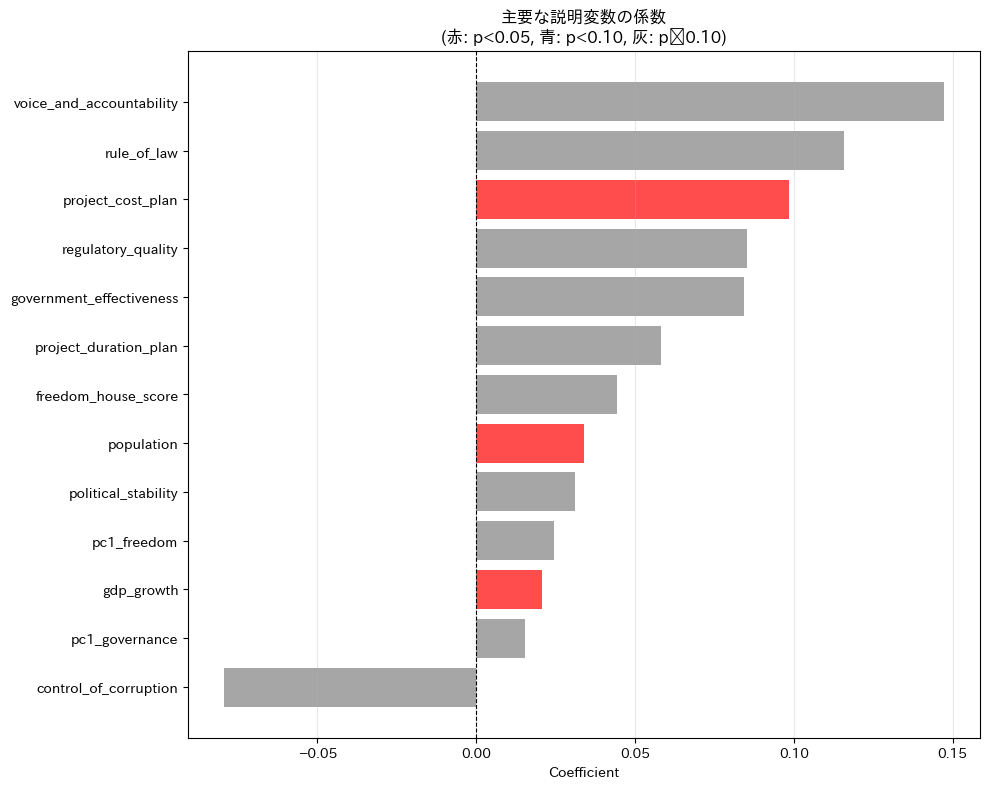


係数一覧:
                Variable  Coefficient  Std_Error  P_value
   control_of_corruption    -0.079374   0.117437 0.499190
          pc1_governance     0.015269   0.057247 0.789712
              gdp_growth     0.020805   0.008942 0.020079
             pc1_freedom     0.024451   0.172701 0.887425
     political_stability     0.031229   0.041382 0.450547
              population     0.033799   0.016427 0.039767
     freedom_house_score     0.044283   0.045327 0.328697
   project_duration_plan     0.058288   0.052909 0.270746
government_effectiveness     0.084319   0.115391 0.465035
      regulatory_quality     0.085383   0.079116 0.280623
       project_cost_plan     0.098558   0.032956 0.002819
             rule_of_law     0.115874   0.128204 0.366199
voice_and_accountability     0.147311   0.230850 0.523465


In [114]:
# 数値変数とPCA変数の係数を抽出
coef_data = []
for var in numeric_vars:
    if var in model1.params.index:
        coef_data.append({
            'Variable': var,
            'Coefficient': model1.params[var],
            'Std_Error': model1.bse[var],
            'P_value': model1.pvalues[var]
        })

coef_df = pd.DataFrame(coef_data)
coef_df = coef_df.sort_values('Coefficient')

# 可視化
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['red' if p < 0.05 else 'blue' if p < 0.10 else 'gray' for p in coef_df['P_value']]
ax.barh(coef_df['Variable'], coef_df['Coefficient'], color=colors, alpha=0.7)
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Coefficient')
ax.set_title('主要な説明変数の係数\n(赤: p<0.05, 青: p<0.10, 灰: p≥0.10)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n係数一覧:")
print(coef_df.to_string(index=False))

## 11. type（援助形態）の係数

In [115]:
# type変数の係数を抽出
type_coefs = [(param, model1.params[param], model1.pvalues[param]) 
              for param in model1.params.index if 'C(type)' in param]

if type_coefs:
    type_df = pd.DataFrame(type_coefs, columns=['Parameter', 'Coefficient', 'P_value'])
    print("援助形態 (type) の係数:")
    print(type_df.to_string(index=False))
else:
    print("type変数の係数が見つかりませんでした")

援助形態 (type) の係数:
    Parameter  Coefficient  P_value
C(type)[T.有償]    -0.305509 0.007886
C(type)[T.無償]     0.218857 0.002036
C(type)[T.複合]    -0.215015 0.350683


## 12. region_detail（地域）の係数

In [116]:
# region_detail変数の係数を抽出
region_coefs = [(param, model1.params[param], model1.pvalues[param]) 
                for param in model1.params.index if 'C(region_detail)' in param]

if region_coefs:
    region_df = pd.DataFrame(region_coefs, columns=['Parameter', 'Coefficient', 'P_value'])
    region_df = region_df.sort_values('Coefficient', ascending=False)
    print("地域 (region_detail) の係数:")
    print(region_df.to_string(index=False))
else:
    print("region_detail変数の係数が見つかりませんでした")

地域 (region_detail) の係数:
                 Parameter  Coefficient  P_value
   C(region_detail)[T.北中米]     0.371682 0.288418
  C(region_detail)[T.東アジア]     0.160557 0.537582
  C(region_detail)[T.南アジア]     0.029128 0.895539
 C(region_detail)[T.北アフリカ]     0.013996 0.953481
C(region_detail)[T.中央アメリカ]    -0.007236 0.976834
  C(region_detail)[T.西アジア]    -0.040155 0.874729
    C(region_detail)[T.東欧]    -0.040299 0.895512
C(region_detail)[T.南ヨーロッパ]    -0.064537 0.805001
 C(region_detail)[T.中央アジア]    -0.070492 0.787413
 C(region_detail)[T.東南アジア]    -0.088301 0.704043
 C(region_detail)[T.南アメリカ]    -0.108445 0.654578
 C(region_detail)[T.ポリネシア]    -0.133430 0.597397
C(region_detail)[T.南部アフリカ]    -0.207675 0.373417
 C(region_detail)[T.メラネシア]    -0.210577 0.379777
 C(region_detail)[T.西アフリカ]    -0.246931 0.281901
 C(region_detail)[T.東アフリカ]    -0.330361 0.146649
  C(region_detail)[T.カリブ海]    -0.350495 0.196813
C(region_detail)[T.中央アフリカ]    -0.356453 0.203159


## 13. モデル診断

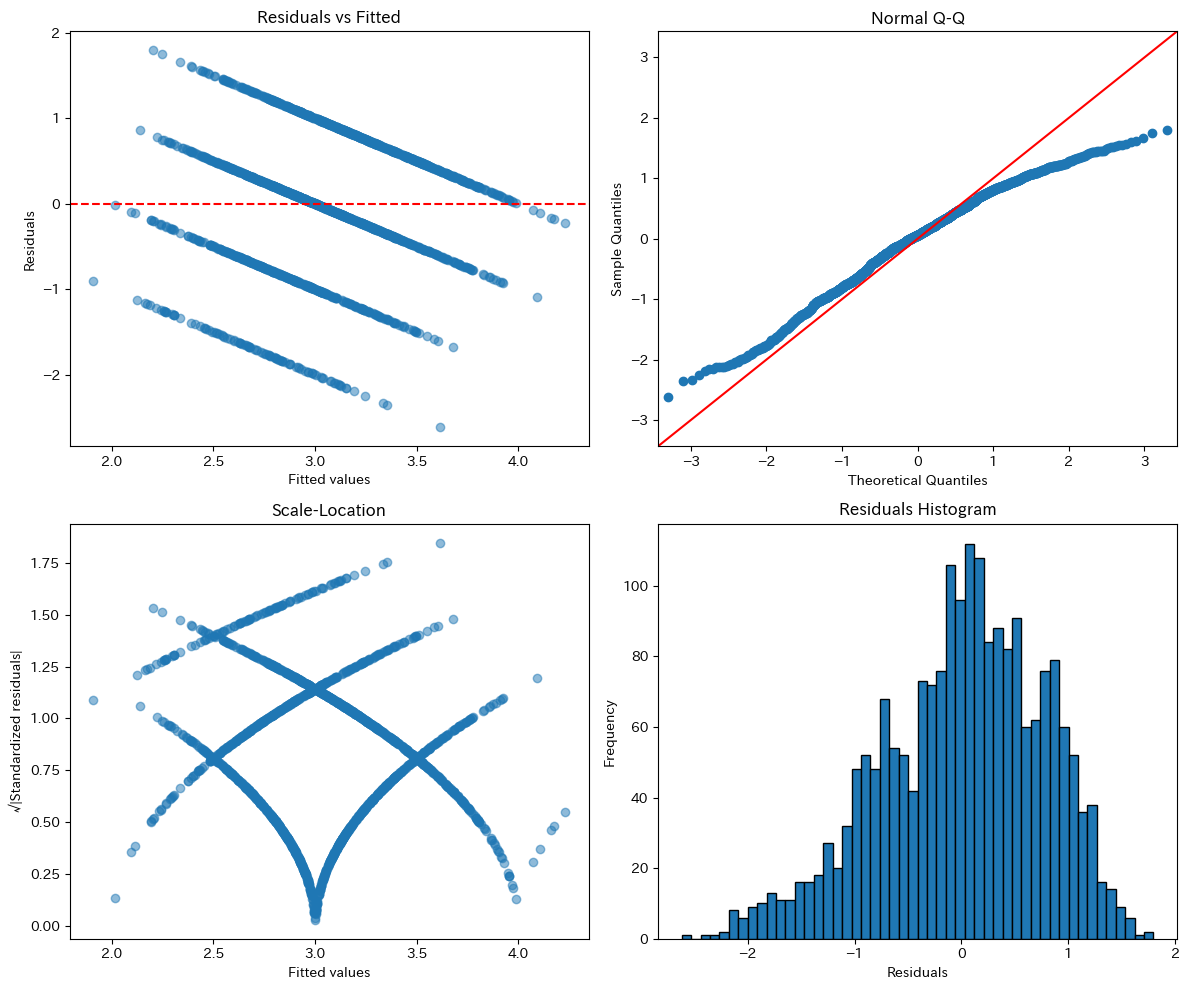

In [117]:
# 残差プロット
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. 残差 vs 予測値
axes[0, 0].scatter(model1.fittedvalues, model1.resid, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Fitted values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')

# 2. Q-Qプロット
sm.qqplot(model1.resid, line='45', ax=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q')

# 3. Scale-Location
standardized_resid = model1.resid / np.std(model1.resid)
axes[1, 0].scatter(model1.fittedvalues, np.sqrt(np.abs(standardized_resid)), alpha=0.5)
axes[1, 0].set_xlabel('Fitted values')
axes[1, 0].set_ylabel('√|Standardized residuals|')
axes[1, 0].set_title('Scale-Location')

# 4. 残差のヒストグラム
axes[1, 1].hist(model1.resid, bins=50, edgecolor='black')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Residuals Histogram')

plt.tight_layout()
plt.show()

## 14. 結果のエクスポート

In [118]:
# 結果を保存
output_file = '../regression_results.txt'

with open(output_file, 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("ODA プロジェクト評価 回帰分析結果 (PCA適用版)\n")
    f.write("="*80 + "\n\n")
    
    f.write("モデル1: プーリングOLS\n")
    f.write("-"*80 + "\n")
    f.write(model1.summary().as_text())
    f.write("\n\n")
    
    f.write("="*80 + "\n")
    f.write("VIF (分散拡大要因)\n")
    f.write("="*80 + "\n")
    f.write(vif_data.to_string())
    f.write("\n\n")

print(f"結果を {output_file} に保存しました")

結果を ../regression_results.txt に保存しました


## 15. セクターフラグの有意な係数

In [119]:
# セクターフラグ変数の係数を抽出（有意なもののみ）
sector_coefs = []
for param in model1.params.index:
    for flag in cat_flg:
        if flag in param:
            sector_coefs.append({
                'Sector': param,
                'Coefficient': model1.params[param],
                'P_value': model1.pvalues[param],
                'Significant': '***' if model1.pvalues[param] < 0.01 else '**' if model1.pvalues[param] < 0.05 else '*' if model1.pvalues[param] < 0.10 else ''
            })

if sector_coefs:
    sector_df = pd.DataFrame(sector_coefs)
    sector_df = sector_df[sector_df['P_value'] < 0.10].sort_values('Coefficient', ascending=False)
    
    if len(sector_df) > 0:
        print("有意なセクターフラグの係数 (p < 0.10):")
        print(sector_df.to_string(index=False))
    else:
        print("有意なセクターフラグの係数はありませんでした (p < 0.10)")
else:
    print("セクターフラグの係数が見つかりませんでした")

有意なセクターフラグの係数 (p < 0.10):
                  Sector  Coefficient  P_value Significant
Q('その他_flg_fix')[T.True]     0.673546 0.010154          **
 Q('放送_flg_fix')[T.True]     0.461356 0.035014          **
 Q('水産_flg_fix')[T.True]    -0.301531 0.053892           *


## 16. モデルサマリー統計

In [120]:
# モデルの主要統計量をまとめる
summary_stats = pd.DataFrame({
    '統計量': ['観測数', 'R-squared', 'Adj. R-squared', 'F-statistic', 'Prob (F-statistic)', 'AIC', 'BIC'],
    '値': [
        int(model1.nobs),
        f"{model1.rsquared:.4f}",
        f"{model1.rsquared_adj:.4f}",
        f"{model1.fvalue:.4f}",
        f"{model1.f_pvalue:.4e}",
        f"{model1.aic:.2f}",
        f"{model1.bic:.2f}"
    ]
})

print("\nモデルサマリー統計:")
print(summary_stats.to_string(index=False))


モデルサマリー統計:
               統計量          値
               観測数       2065
         R-squared     0.1815
    Adj. R-squared     0.1506
       F-statistic     5.8808
Prob (F-statistic) 7.5449e-47
               AIC    4912.83
               BIC    5340.93
